In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *


IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [17]:
plot_summary(var,t,resample_interval)

1


NameError: name 'seasonal_results' is not defined

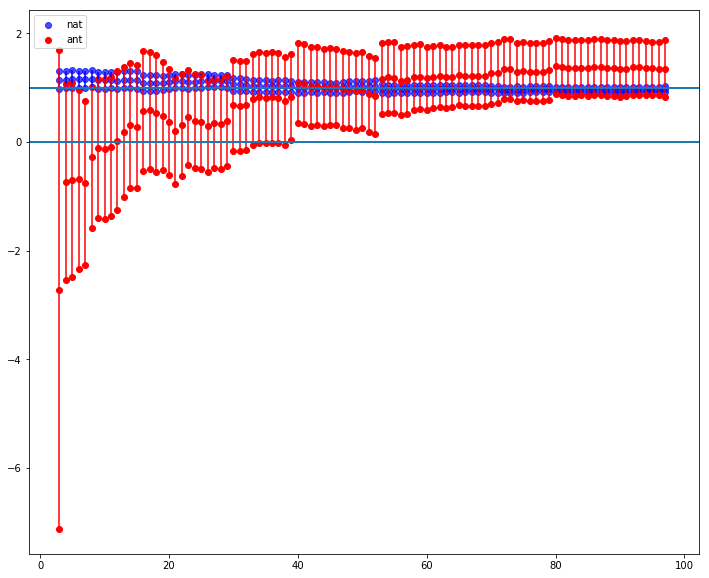

In [46]:
'''
MAIN function for performing perfect_model testing for one variable in d4PDF
'''

var = 'FWI'
t = 60
resample_interval = 'annual'

with open("/nesi/project/niwa02986/queenle/data/fire_OF/PM_summaries/"+var+"_" +resample_interval + "_trunc_" + str(t) + ".csv", 'w') as file:
    file.write('ensemble_member,ant_upper,ant_lower,ant_best,nat_upper,nat_lower,nat_best')

    for member in range(1,101):
            
        print(member)

        if member == 100:
            number = '100'
        else:
            number = '00' + str(member) if member < 10 else '0' + str(member)

        PM_results = perfect_model_test(var,number,resample_interval,t)

        for result in PM_results:
            file.write('\n' +result)

        del PM_results          
            
plot_summary(var,t,resample_interval)

In [50]:
def get_obs_data(var, mem, resample_interval):
            
    da = xr.open_dataarray("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/"+ var + '_HPB_m' + mem + '.nc')

    if resample_interval != 'annual':
        da = da.resample(time=resample_interval).mean()

    da = da.sel(time=slice("1951","2021"))
    da = da.stack(pixel=("latitude", "longitude"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    del da
    
    return(array)


In [51]:
def get_mean_and_noise(var,scen, mem, resample_interval):
    
    ens_mean_sub_member = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/means/' + var + '_'+scen+'_ensMeanSub_m'+mem+'.nc')
    
    if resample_interval != 'annual':
        ens_mean_sub_member = ens_mean_sub_member.resample(time=resample_interval).mean()
        
    ens_mean_sub_member = ens_mean_sub_member.sel(time=slice("1951","2021"))
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if number == mem:
            continue

        mem_da = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/'+ var + '_'+scen+'_m' + number + '.nc')

        if resample_interval != 'annual':
            mem_da = mem_da.resample(time=resample_interval).mean()
            
        mem_da = mem_da.sel(time=slice("1951","2021"))
        
        diff = mem_da - ens_mean_sub_member

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
        del mem_da
        del diff_array

    ens_mean_sub_member = ens_mean_sub_member.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean_sub_member = ens_mean_sub_member.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean_sub_member.values.flatten()

    del ens_mean_sub_member
    
    return((ens_mean_array, np.array(noise)))


In [52]:
def scan_optimal_fingerprinting(var,number,resample_interval):
    
    IDL.retall

    all_ens_mean,noise_all = get_mean_and_noise(var,'HPB', number, resample_interval)
    nat_ens_mean,noise_nat = get_mean_and_noise(var,'HPB_NAT', number, resample_interval)

    data_obs = get_obs_data(var, number, resample_interval)
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    data_noise_1 = np.concatenate((noise_all[:49],noise_nat[:49]))
    data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

    trunc = np.array([i for i in range(3,98)])

    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est")

    #beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    
    return scan_beta_est

In [53]:
def perfect_model_test(var, number, resample_interval, trunc):

    fig,axs = plt.subplots(figsize=(12,10))

    scan_beta_est = scan_optimal_fingerprinting(var,number,resample_interval)

    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        axs.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
        axs.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

        axs.vlines(j+3,low_2,up_2,colors=['blue'])
        axs.vlines(j+3,low_1,up_1,colors=['red'])

        axs.axhline(0,-0.5,1.5)
        axs.axhline(1,-0.5,1.5)

    axs.legend()

    #['ensemble_member','ant_upper','ant_lower','ant_best','nat_upper','nat_lower','nat_best']
    result = number+','+\
             str(scan_beta_est[t-3][2][0])+','+str(scan_beta_est[t-3][1][0])+','+str(scan_beta_est[t-3][0][0])+','+\
             str(scan_beta_est[t-3][2][1])+','+str(scan_beta_est[t-3][1][1])+','+str(scan_beta_est[t-3][0][1])


    plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/perfect_model/'+var+'/6month_fire_season/'+resample_interval+'/' + 'PM_ens_' + number + '.png')
    plt.close(fig)
    
    return result


In [54]:
def plot_summary(var,t,resample_interval):
    
    summary_df = pd.read_csv("/nesi/project/niwa02986/queenle/data/fire_OF/PM_summaries/"+var+"_" +resample_interval + "_trunc_" + str(t) + ".csv")
        
    for sort_type in ['nat_best','ant_best']:

        fig,axs = plt.subplots(figsize=(12,10))

        sorted_df = summary_df.sort_values(by=sort_type)

        axs.scatter([i for i in range(len(sorted_df.nat_upper))],sorted_df.nat_upper,c='blue',label='nat')
        axs.scatter([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,c='blue',label='')
        axs.scatter([i for i in range(len(sorted_df.nat_best))],sorted_df.nat_best,c='blue',label='')

        axs.scatter([i for i in range(len(sorted_df.ant_upper))],sorted_df.ant_upper,c='red',label='ant')
        axs.scatter([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,c='red',label='')
        axs.scatter([i for i in range(len(sorted_df.ant_best))],sorted_df.ant_best,c='red',label='')

        axs.vlines([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,sorted_df.nat_upper,colors=['blue'],label='')
        axs.vlines([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,sorted_df.ant_upper,colors=['red'],label='')

        axs.axhline(0,-0.5,1.5)
        axs.axhline(1,-0.5,1.5)

        axs.set_title('trunc = ' + str(t))

        axs.legend()

        plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/perfect_model/'+var+'/6month_fire_season/' + resample_interval + '/' + 'PM_ensemble_summary_'+sort_type+'_sort.png')

        plt.close(fig)